# ChEMBL webresource client examples

The library helps accessing ChEMBL data and cheminformatics tools from Python. You don't need to know how to write SQL. You don't need to know how to interact with REST APIs. You don't need to compile or install any cheminformatics frameworks. Results are cached.

The client handles interaction with the HTTPS protocol and caches all results in the local file system for faster retrieval. Abstracting away all network-related tasks, the client provides the end user with a convenient interface, giving the impression of working with a local resource. Design is based on the Django QuerySet interface. The client also implements lazy evaluation of results, which means it will only evaluate a request for data when a value is required. This approach reduces number of network requests and increases performance.

### Helper function: Show Dictionary structures

In [ ]:
def dict_structure(d, indent="", start_icon="┌── "):
    """
    Prints an ASCII tree of nested dictionaries, depicting all keys

    Args:
    d: Python dictionary
    indent: Set indentation (default: "")
    start_icon: Tree start icon (default: "┌── ")
    """
    last = len(d) - 1
    for i, (k, v) in enumerate(d.items()): 
        branch = "└── " if i == last else (start_icon if i == 0 else "├── ")
        print(indent + branch + str(k))
        if isinstance(v, dict):
            prefix = "    " if i == last else "│   "
            dict_structure(v, indent + prefix, start_icon="├── ")

## Available data entities

You can list available data entities using the following code

In [1]:
from chembl_webresource_client.new_client import new_client

available_resources = [resource for resource in dir(new_client) if not resource.startswith('_')]
print(available_resources)

c:\Users\jan.krumbach\Documents\projects_software\chembl_webresource_client\chembl_webresource_client\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


['activity', 'activity_supplementary_data_by_activity', 'assay', 'assay_class', 'atc_class', 'binding_site', 'biotherapeutic', 'cell_line', 'chembl_id_lookup', 'chembl_release', 'compound_record', 'compound_structural_alert', 'description', 'document', 'document_similarity', 'drug', 'drug_indication', 'drug_warning', 'go_slim', 'image', 'mechanism', 'metabolism', 'molecule', 'molecule_form', 'official', 'organism', 'protein_classification', 'similarity', 'source', 'substructure', 'target', 'target_component', 'target_relation', 'tissue', 'xref_source']


## Available filters

The design of the client is based on Django QuerySet (https://docs.djangoproject.com/en/1.11/ref/models/querysets) and most important lookup types are supported. These are:

- exact
- iexact
- contains
- icontains
- in
- gt
- gte
- lt
- lte
- startswith
- istartswith
- endswith
- iendswith
- range
- isnull
- regex
- iregex

## Only operator

`only` is a special method allowing to limit the results to a selected set of fields. only should take a single argument: a list of fields that should be included in result. Specified fields have to exists in the endpoint against which only is executed. Using only will usually make an API call faster because less information returned will save bandwidth. The API logic will also check if any SQL joins are necessary to return the specified field and exclude unnecessary joins with critically improves performance.

Please note that only has one limitation: a list of fields will ignore nested fields i.e. calling only(['molecule_properties__alogp']) is equivalent to only(['molecule_properties']).

For many 2 many relationships only will not make any SQL join optimisation.

# Molecules

Molecule records may be retrieved in a number of ways, such as lookup of single molecules using various identifiers or searching for compounds via similarity.

## Find a molecule by pref_name


In [2]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
mols = molecule.filter(pref_name__iexact='aspirin')
mols

[{'atc_classifications': ['B01AC06', 'N02BA01', 'N02BA51', 'A01AD05', 'N02BA71'], 'availability_type': 2, 'biotherapeutic': None, 'black_box_warning': 0, 'chemical_probe': 0, 'chirality': 2, 'cross_references': [{'xref_id': 'aspirin', 'xref_name': 'aspirin', 'xref_src': 'DailyMed'}], 'dosed_ingredient': True, 'first_approval': 1950, 'first_in_class': 0, 'helm_notation': None, 'inorganic_flag': 0, 'max_phase': '4.0', 'molecule_chembl_id': 'CHEMBL25', 'molecule_hierarchy': {'active_chembl_id': 'CHEMBL25', 'molecule_chembl_id': 'CHEMBL25', 'parent_chembl_id': 'CHEMBL25'}, 'molecule_properties': {'alogp': '1.31', 'aromatic_rings': 1, 'full_molformula': 'C9H8O4', 'full_mwt': '180.16', 'hba': 3, 'hbd': 1, 'heavy_atoms': 13, 'mw_freebase': '180.16', 'np_likeness_score': '0.12', 'num_ro5_violations': 0, 'psa': '63.60', 'qed_weighted': '0.55', 'ro3_pass': 'N', 'rtb': 2}, 'molecule_structures': {'canonical_smiles': 'CC(=O)Oc1ccccc1C(=O)O', 'molfile': '\n     RDKit          2D\n\n 13 13  0  0  0 

In [3]:
# Get SMILES
print(mols[0]["molecule_structures"]["canonical_smiles"])

CC(=O)Oc1ccccc1C(=O)O


## Find a molecule by its synonyms

- in case it is not found by pref_name
- Use the `only` method where you can specify fields you want to be included in response

In [4]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
mols = molecule.filter(molecule_synonyms__molecule_synonym__iexact='viagra').only('molecule_chembl_id')
mols

[{'molecule_chembl_id': 'CHEMBL1737'}]

In [5]:
# -> Ignores Subfields
viag_smiles = molecule.filter(molecule_synonyms__molecule_synonym__iexact="viagra").only("molecule_structures__canonical_smiles")
print(viag_smiles)


[{'molecule_structures': {'canonical_smiles': 'CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12.O=C(O)CC(O)(CC(=O)O)C(=O)O', 'molfile': '\n     RDKit          2D\n\n 46 48  0  0  0  0  0  0  0  0999 V2000\n    6.2667   -0.4375    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    6.8792   -0.7917    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.6542   -0.7917    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.9042    0.1750    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    7.4917   -0.4375    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.6542   -1.5000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    5.2000    0.1708    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    7.4917    0.2708    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    6.2667   -1.8542    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    6.6125    0.1750    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    6.2542    0.7958    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\

## Get a single molecule by ChEMBL id

All the main entities in the ChEMBL database have a ChEMBL ID. It is a stable identifier designed for straightforward lookup of data.

In [6]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
m1 = molecule.filter(chembl_id='CHEMBL192').only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])
m1

[{'molecule_chembl_id': 'CHEMBL192', 'molecule_structures': {'canonical_smiles': 'CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12', 'molfile': '\n     RDKit          2D\n\n 33 36  0  0  0  0  0  0  0  0999 V2000\n    2.1000   -0.0042    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.1000    0.7000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.5375   -0.0042    0.0000 S   0  0  0  0  0  0  0  0  0  0  0  0\n    1.4917   -0.3667    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8792   -0.0042    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.8042    0.9083    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    1.4917    1.0625    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8792    0.6833    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    3.2042    0.3458    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n    2.8042   -0.2417    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.2875   -0.3750    0.0000 C   0  0  0  0  0  0  0  0  0  

In [82]:
dict_structure(m1[0])

┌── molecule_chembl_id
├── molecule_structures
│   ├── canonical_smiles
│   ├── molfile
│   ├── standard_inchi
│   └── standard_inchi_key
└── pref_name


## Get many molecules by id

In [7]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
mols = molecule.filter(molecule_chembl_id__in=['CHEMBL25', 'CHEMBL192', 'CHEMBL27']).only(['molecule_chembl_id', 'pref_name'])
mols

[{'molecule_chembl_id': 'CHEMBL25', 'pref_name': 'ASPIRIN'}, {'molecule_chembl_id': 'CHEMBL27', 'pref_name': 'PROPRANOLOL'}, {'molecule_chembl_id': 'CHEMBL192', 'pref_name': 'SILDENAFIL'}]

## Display a molecule image

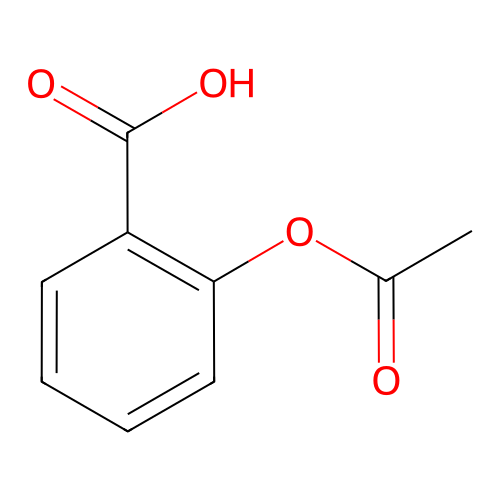

In [8]:
from chembl_webresource_client.new_client import new_client
from IPython.display import SVG

image = new_client.image
image.set_format('svg')
SVG(image.get('CHEMBL25'))

## Get a single molecule by standard inchi key

- InChiKey: Fixed-length, 27-character long, hashed version of an InChi (International Chemical Identifier)-String.
    - Contains the full InChi-Key

In [54]:
from chembl_webresource_client.new_client import new_client
molecule = new_client.molecule
mol_unfiltered = molecule.filter(molecule_structures__standard_inchi_key='BSYNRYMUTXBXSQ-UHFFFAOYSA-N')
# Show standard InChi-String
print(mol_unfiltered[0]["molecule_structures"]["standard_inchi"])

InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)


In [72]:
dict_structure(mol_unfiltered[0])

├── atc_classifications
├── availability_type
├── biotherapeutic
├── black_box_warning
├── chemical_probe
├── chirality
├── cross_references
├── dosed_ingredient
├── first_approval
├── first_in_class
├── helm_notation
├── inorganic_flag
├── max_phase
├── molecule_chembl_id
├── molecule_hierarchy
│   ├── active_chembl_id
│   ├── molecule_chembl_id
│   └── parent_chembl_id
├── molecule_properties
│   ├── alogp
│   ├── aromatic_rings
│   ├── full_molformula
│   ├── full_mwt
│   ├── hba
│   ├── hbd
│   ├── heavy_atoms
│   ├── mw_freebase
│   ├── np_likeness_score
│   ├── num_ro5_violations
│   ├── psa
│   ├── qed_weighted
│   ├── ro3_pass
│   └── rtb
├── molecule_structures
│   ├── canonical_smiles
│   ├── molfile
│   ├── standard_inchi
│   └── standard_inchi_key
├── molecule_synonyms
├── molecule_type
├── natural_product
├── oral
├── orphan
├── parenteral
├── polymer_flag
├── pref_name
├── prodrug
├── structure_type
├── therapeutic_flag
├── topical
├── usan_stem
├── usan_stem_definition
├

In [55]:
mol = molecule.filter(molecule_structures__standard_inchi_key='BSYNRYMUTXBXSQ-UHFFFAOYSA-N').only(['molecule_chembl_id', 'pref_name', 'molecule_structures'])
mol

[{'molecule_chembl_id': 'CHEMBL25', 'molecule_structures': {'canonical_smiles': 'CC(=O)Oc1ccccc1C(=O)O', 'molfile': '\n     RDKit          2D\n\n 13 13  0  0  0  0  0  0  0  0999 V2000\n   19.8052   -4.2758    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   19.8040   -5.0953    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   20.5121   -5.5043    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   21.2217   -5.0948    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   21.2189   -4.2722    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   20.5103   -3.8669    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   20.5078   -3.0497    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   21.2143   -2.6390    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   19.7989   -2.6432    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   21.9250   -3.8609    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   22.6343   -4.2668    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   23.3405   -3.8556    0.0000 C 

## Find compounds similar to given SMILES query with similarity threshold of 70%

In [83]:
from chembl_webresource_client.new_client import new_client

similarity = new_client.similarity
res = similarity.filter(smiles="CO[C@@H](CCC#C\C=C/CCCC(C)CCCCC=C)C(=O)[O-]", similarity=70).only(['molecule_chembl_id', 'similarity'])
for i in res:
    print(i)

{'molecule_chembl_id': 'CHEMBL478779', 'similarity': '100'}
{'molecule_chembl_id': 'CHEMBL477889', 'similarity': '100'}
{'molecule_chembl_id': 'CHEMBL477888', 'similarity': '100'}
{'molecule_chembl_id': 'CHEMBL449975', 'similarity': '72.9166686534881591796875'}
{'molecule_chembl_id': 'CHEMBL499009', 'similarity': '72.9166686534881591796875'}
{'molecule_chembl_id': 'CHEMBL2304268', 'similarity': '71.428573131561279296875'}


## Find compounds similar to aspirin (CHEMBL25) with similarity threshold of 70%


In [84]:
from chembl_webresource_client.new_client import new_client

similarity = new_client.similarity
res = similarity.filter(chembl_id='CHEMBL25', similarity=70).only(['molecule_chembl_id', 'pref_name', 'similarity'])
res

[{'molecule_chembl_id': 'CHEMBL2296002', 'pref_name': None, 'similarity': '100'}, {'molecule_chembl_id': 'CHEMBL1697753', 'pref_name': 'ASPIRIN DL-LYSINE', 'similarity': '100'}, {'molecule_chembl_id': 'CHEMBL3833404', 'pref_name': 'CARBASPIRIN', 'similarity': '88.8888895511627197265625'}, {'molecule_chembl_id': 'CHEMBL3833325', 'pref_name': 'CARBASPIRIN CALCIUM', 'similarity': '88.8888895511627197265625'}, '...(remaining elements truncated)...']

## Find compounds with the same connectivity

In [85]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
res = molecule.filter(molecule_structures__canonical_smiles__connectivity='CN(C)C(=N)N=C(N)N').only(['molecule_chembl_id', 'pref_name'])
for i in res:
    print(i)

{'molecule_chembl_id': 'CHEMBL1431', 'pref_name': 'METFORMIN'}
{'molecule_chembl_id': 'CHEMBL1703', 'pref_name': 'METFORMIN HYDROCHLORIDE'}
{'molecule_chembl_id': 'CHEMBL3094198', 'pref_name': None}


## Get all approved drugs

using `order_by` to sort them by molecular weight

In [ ]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
approved_drugs = molecule.filter(max_phase=4).order_by('molecule_properties__mw_freebase')
print(len(approved_drugs))

4005


In [91]:
dict_structure(approved_drugs[0])

┌── atc_classifications
├── availability_type
├── biotherapeutic
├── black_box_warning
├── chemical_probe
├── chirality
├── cross_references
├── dosed_ingredient
├── first_approval
├── first_in_class
├── helm_notation
├── inorganic_flag
├── max_phase
├── molecule_chembl_id
├── molecule_hierarchy
│   ├── active_chembl_id
│   ├── molecule_chembl_id
│   └── parent_chembl_id
├── molecule_properties
│   ├── alogp
│   ├── aromatic_rings
│   ├── full_molformula
│   ├── full_mwt
│   ├── hba
│   ├── hbd
│   ├── heavy_atoms
│   ├── mw_freebase
│   ├── np_likeness_score
│   ├── num_ro5_violations
│   ├── psa
│   ├── qed_weighted
│   ├── ro3_pass
│   └── rtb
├── molecule_structures
│   ├── canonical_smiles
│   ├── molfile
│   ├── standard_inchi
│   └── standard_inchi_key
├── molecule_synonyms
├── molecule_type
├── natural_product
├── oral
├── orphan
├── parenteral
├── polymer_flag
├── pref_name
├── prodrug
├── structure_type
├── therapeutic_flag
├── topical
├── usan_stem
├── usan_stem_definition
├

- Note: This is the number of small molecules in phase four. For a more curated set (with less biologics, vaccines):

In [93]:
# Alternative
drug = new_client.drug
drugs_approved = drug.filter(max_phase=4)
print(len(drugs_approved))

2830


In [94]:
dict_structure(drugs_approved[0])

┌── applicants
├── atc_classification
├── availability_type
├── biotherapeutic
├── black_box
├── black_box_warning
├── chirality
├── drug_type
├── first_approval
├── first_in_class
├── helm_notation
├── max_phase
├── molecule_chembl_id
├── molecule_properties
│   ├── alogp
│   ├── aromatic_rings
│   ├── full_molformula
│   ├── full_mwt
│   ├── hba
│   ├── hbd
│   ├── heavy_atoms
│   ├── mw_freebase
│   ├── np_likeness_score
│   ├── num_ro5_violations
│   ├── psa
│   ├── qed_weighted
│   ├── ro3_pass
│   └── rtb
├── molecule_structures
│   ├── canonical_smiles
│   ├── molfile
│   ├── standard_inchi
│   └── standard_inchi_key
├── molecule_synonyms
├── ob_patent
├── oral
├── parenteral
├── prodrug
├── research_codes
├── rule_of_five
├── sc_patent
├── synonyms
├── topical
├── usan_stem
├── usan_stem_definition
├── usan_stem_substem
├── usan_year
└── withdrawn_flag


- Combinations of drugs, different fomulations, all withdrawn drugs etc. are not separately listed &rarr; inflate the number greatly
    - Full DB dump required to access these?
    - `drug`: Metadata, regulatory information, indications, mechanisms, warnings
    - `molecule`: structural entity
    - Other alternative: 
        - `biotherapeutic` (structure-related sequences like HELM [Hierarchical Editing Language for Macromolecules] notation for biomol. structure representation); but no clincial phase field


In [100]:
# Get biologics in both categories
biologics_categories = [
    "Protein",
    "Antibody",
    "Oligonucleotide",
    "Enzyme",
    "Cell",
    "Gene"
]

molecule_biologics = molecule.filter(max_phase=4).filter(
    molecule_type__in=biologics_categories
)

print(len(molecule_biologics))

516


In [ ]:
# No max phase field
all_biotherapeutics = new_client.biotherapeutic
approved_biotherapeutics = all_biotherapeutics.filter(max_phase=4)
print(f"All biotherapeutics: {len(all_biotherapeutics)}")
print(f"Approved biotherapeutics: {len(approved_biotherapeutics)}")

All biotherapeutics: 23921
Approved biotherapeutics: 23921


In [104]:
dict_structure(approved_biotherapeutics[0])

┌── biocomponents
├── description
├── helm_notation
└── molecule_chembl_id


In [105]:
approved_biotherapeutics[0]["helm_notation"]

'PEPTIDE1{A.L.Y.A.S.K.L.S.[am]}$$$$'

## Get approved drugs for lung cancer

In [14]:
from chembl_webresource_client.new_client import new_client

drug_indication = new_client.drug_indication
molecules = new_client.molecule

lung_cancer_ind = drug_indication.filter(efo_term__icontains="LUNG CARCINOMA")
lung_cancer_mols = molecules.filter(
    molecule_chembl_id__in=[x['molecule_chembl_id'] for x in lung_cancer_ind])

len(lung_cancer_mols)

787

In [108]:
print(lung_cancer_ind)

[{'drugind_id': 22637, 'efo_id': 'EFO:0003060', 'efo_term': 'non-small cell lung carcinoma', 'indication_refs': [{'ref_id': 'NCT02364609,NCT02438722,NCT04814056', 'ref_type': 'ClinicalTrials', 'ref_url': 'https://clinicaltrials.gov/search?term=NCT02364609%20NCT02438722%20NCT04814056'}, {'ref_id': 'fd638e5e-8032-e7ca-0179-95e96ab5d387', 'ref_type': 'DailyMed', 'ref_url': 'https://dailymed.nlm.nih.gov/dailymed/drugInfo.cfm?setid=fd638e5e-8032-e7ca-0179-95e96ab5d387'}, {'ref_id': 'EMEA/H/C/002280', 'ref_type': 'EMA', 'ref_url': 'https://www.ema.europa.eu/en/medicines/human/EPAR/giotrif'}], 'max_phase_for_ind': '4.0', 'mesh_heading': 'Carcinoma, Non-Small-Cell Lung', 'mesh_id': 'D002289', 'molecule_chembl_id': 'CHEMBL2105712', 'parent_molecule_chembl_id': 'CHEMBL1173655'}, {'drugind_id': 22696, 'efo_id': 'EFO:0003060', 'efo_term': 'non-small cell lung carcinoma', 'indication_refs': [{'ref_id': 'NCT02161991,NCT02646020', 'ref_type': 'ClinicalTrials', 'ref_url': 'https://clinicaltrials.gov/s

In [106]:
print(dict_structure(drug_indication[0]))

┌── drugind_id
├── efo_id
├── efo_term
├── indication_refs
├── max_phase_for_ind
├── mesh_heading
├── mesh_id
├── molecule_chembl_id
└── parent_molecule_chembl_id
None


## Filter drugs by approval year and name

In [109]:
from chembl_webresource_client.new_client import new_client

drug = new_client.drug
res = drug.filter(first_approval__gte=1980).filter(usan_stem="-azosin")
res

[{'applicants': ['Jubilant Cadista Pharmaceuticals Inc', 'Ivax Pharmaceuticals Inc Sub Teva Pharmaceuticals Usa', 'Sandoz Inc', 'Apnar Pharma Lp', 'Novitium Pharma Llc', 'Norvium Bioscience Llc', 'Heritage Pharma Labs Inc Dba Avet Pharmaceuticals Labs Inc', 'Hikma Pharmaceuticals International Ltd', 'Ranbaxy Laboratories Ltd', 'Chartwell Rx Sciences Llc'], 'atc_classification': [{'code': 'G04CA03', 'description': 'GENITO URINARY SYSTEM AND SEX HORMONES: UROLOGICALS: DRUGS USED IN BENIGN PROSTATIC HYPERTROPHY: Alpha-adrenoreceptor antagonists'}], 'availability_type': 1, 'biotherapeutic': None, 'black_box': 0, 'black_box_warning': '0', 'chirality': 0, 'drug_type': 1, 'first_approval': 1987, 'first_in_class': 0, 'helm_notation': None, 'max_phase': '4.0', 'molecule_chembl_id': 'CHEMBL611', 'molecule_properties': {'alogp': '1.06', 'aromatic_rings': 2, 'full_molformula': 'C19H25N5O4', 'full_mwt': '387.44', 'hba': 8, 'hbd': 1, 'heavy_atoms': 28, 'mw_freebase': '387.44', 'np_likeness_score': '

## Get all biotherapeutic molecules

In [110]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
biotherapeutics = molecule.filter(biotherapeutic__isnull=False)
len(biotherapeutics)

23921

## Get molecules with molecular weight <= 300

In [111]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
light_molecules = molecule.filter(molecule_properties__mw_freebase__lte=300)

len(light_molecules)

448087

## Get molecules with molecular weight <= 300 AND pref_name ending with nib

In [112]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
light_nib_molecules = molecule.filter(molecule_properties__mw_freebase__lte=300, pref_name__iendswith="nib").only(['molecule_chembl_id', 'pref_name'])

light_nib_molecules

[{'molecule_chembl_id': 'CHEMBL276711', 'pref_name': 'SEMAXANIB'}, {'molecule_chembl_id': 'CHEMBL4085457', 'pref_name': 'RITLECITINIB'}, {'molecule_chembl_id': 'CHEMBL4594348', 'pref_name': 'ELSUBRUTINIB'}]

## Get all molecules in ChEMBL with no Rule-of-Five violations

In [113]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule
no_violations = molecule.filter(molecule_properties__num_ro5_violations=0)
len(no_violations)

1935757

# Activities

## Get all IC50 activities related to the hERG target

In [114]:
from chembl_webresource_client.new_client import new_client

target = new_client.target
activity = new_client.activity
# Either the correct full name -> More activities
#herg = target.filter(
#    pref_name__iexact='Voltage-gated inwardly rectifying potassium channel KCNH2'
#).only('target_chembl_id')[0]
# ...or hERG as synonym
herg = target.filter(
    molecule_synonyms__molecule_synonym__iexact="herg"
).only("target_chembl_id")[0]

herg_activities = activity.filter(target_chembl_id=herg['target_chembl_id'])

print(len(herg_activities))

746


## Get all activities for a specific target with assay type B (binding):

In [21]:
from chembl_webresource_client.new_client import new_client

activity = new_client.activity
res = activity.filter(target_chembl_id='CHEMBL3938', assay_type='B')

len(res)

1034

In [116]:
print(dict_structure(activity[0]))

┌── action_type
├── activity_comment
├── activity_id
├── activity_properties
├── assay_chembl_id
├── assay_description
├── assay_type
├── assay_variant_accession
├── assay_variant_mutation
├── bao_endpoint
├── bao_format
├── bao_label
├── canonical_smiles
├── data_validity_comment
├── data_validity_description
├── document_chembl_id
├── document_journal
├── document_year
├── ligand_efficiency
├── molecule_chembl_id
├── molecule_pref_name
├── parent_molecule_chembl_id
├── pchembl_value
├── potential_duplicate
├── qudt_units
├── record_id
├── relation
├── src_id
├── standard_flag
├── standard_relation
├── standard_text_value
├── standard_type
├── standard_units
├── standard_upper_value
├── standard_value
├── target_chembl_id
├── target_organism
├── target_pref_name
├── target_tax_id
├── text_value
├── toid
├── type
├── units
├── uo_units
├── upper_value
└── value
None


## Get all activities with a pChEMBL value for a molecule

pChEMBL = –lg(molar IC50, XC50, EC50, AC50, Ki, Kd, or Potency)

In [118]:
from chembl_webresource_client.new_client import new_client

activities = new_client.activity
res = activities.filter(molecule_chembl_id="CHEMBL25", pchembl_value__isnull=False)

len(res)

156

## Search for ADMET-related inhibitor assays (type A)

In [119]:
from chembl_webresource_client.new_client import new_client
assay = new_client.assay
res = assay.filter(description__icontains='inhibit', assay_type='A')
res

[{'aidx': 'CLD0', 'assay_category': None, 'assay_cell_type': None, 'assay_chembl_id': 'CHEMBL884521', 'assay_classifications': [], 'assay_group': None, 'assay_organism': 'Rattus norvegicus', 'assay_parameters': [], 'assay_strain': None, 'assay_subcellular_fraction': None, 'assay_tax_id': 10116, 'assay_test_type': None, 'assay_tissue': None, 'assay_type': 'A', 'assay_type_description': 'ADME', 'bao_format': 'BAO_0000357', 'bao_label': 'single protein format', 'cell_chembl_id': None, 'confidence_description': 'Direct single protein target assigned', 'confidence_score': 9, 'description': 'Inhibition of cytochrome P450 progesterone 15-alpha hydroxylase', 'document_chembl_id': 'CHEMBL1125500', 'relationship_description': 'Direct protein target assigned', 'relationship_type': 'D', 'src_assay_id': None, 'src_id': 1, 'target_chembl_id': 'CHEMBL3705', 'tissue_chembl_id': None, 'variant_sequence': None}, {'aidx': 'CLD0', 'assay_category': None, 'assay_cell_type': None, 'assay_chembl_id': 'CHEMBL

# Tissues

## Get tissue by BTO ID

- "BRENDA tissue ontology" &rarr; tissue, organs, cell types (cross-species)

In [120]:
from chembl_webresource_client.new_client import new_client

tissue = new_client.tissue
res = tissue.filter(bto_id="BTO:0001073")
res

[{'bto_id': 'BTO:0001073', 'caloha_id': 'TS-0798', 'efo_id': 'EFO:0000857', 'pref_name': 'Pituitary gland', 'tissue_chembl_id': 'CHEMBL3638173', 'uberon_id': 'UBERON:0000007'}]

## Get tissue by Caloha id

- Tissue or anatomical structure (human)

In [25]:
from chembl_webresource_client.new_client import new_client

tissue = new_client.tissue
res = tissue.filter(caloha_id="TS-0490")
res

[{'bto_id': 'BTO:0000648', 'caloha_id': 'TS-0490', 'efo_id': 'EFO:0000834', 'pref_name': 'Intestine', 'tissue_chembl_id': 'CHEMBL3638176', 'uberon_id': 'UBERON:0000160'}]

## Get tissue by Uberon id

- body parts, tissues, systems (vertebrates, other metazoans)

In [26]:
from chembl_webresource_client.new_client import new_client

tissue = new_client.tissue
res = tissue.filter(uberon_id="UBERON:0000173")
res

[{'bto_id': 'BTO:0000068', 'caloha_id': 'TS-0034', 'efo_id': None, 'pref_name': 'Amniotic fluid', 'tissue_chembl_id': 'CHEMBL3638177', 'uberon_id': 'UBERON:0000173'}]

## Get tissue by name

In [121]:
from chembl_webresource_client.new_client import new_client

tissue = new_client.tissue
res = tissue.filter(pref_name__istartswith='blood')
res

[{'bto_id': None, 'caloha_id': None, 'efo_id': None, 'pref_name': 'Blood brain barrier', 'tissue_chembl_id': 'CHEMBL3987461', 'uberon_id': 'UBERON:0000120'}, {'bto_id': 'BTO:0000089', 'caloha_id': 'TS-0079', 'efo_id': 'EFO:0000296', 'pref_name': 'Blood', 'tissue_chembl_id': 'CHEMBL3638178', 'uberon_id': 'UBERON:0000178'}, {'bto_id': 'BTO:0001102', 'caloha_id': 'TS-0080', 'efo_id': 'EFO:0000817', 'pref_name': 'Blood vessel', 'tissue_chembl_id': 'CHEMBL3987656', 'uberon_id': 'UBERON:0001981'}, {'bto_id': 'BTO:0000102', 'caloha_id': None, 'efo_id': None, 'pref_name': 'Blood clot', 'tissue_chembl_id': 'CHEMBL3987655', 'uberon_id': 'UBERON:0010210'}, '...(remaining elements truncated)...']

In [123]:
for r in res:
    print(r["pref_name"])

Blood brain barrier
Blood
Blood vessel
Blood clot
Blood/Brain
Blood/Uterus
Blood/Kidney
Blood/Bone
Blood/Heart
Blood/Pancreas
Blood/Muscle
Blood/Ovary
Blood/Spleen
Blood/Esophagus
Blood/Thyroid
Blood/Prostate
Blood/Femur
Blood/Plasma
Blood/Semen
Blood/Testes


# Cells

## Get cell line by cellosaurus id

In [124]:
from chembl_webresource_client.new_client import new_client

cell_line = new_client.cell_line
res = cell_line.filter(cellosaurus_id="CVCL_0417")
res

[{'cell_chembl_id': 'CHEMBL3307686', 'cell_description': 'MDA-MB-435 (Breast metastasis of melanoma cells', 'cell_id': 687, 'cell_name': 'MDA-MB-435', 'cell_source_organism': 'Homo sapiens', 'cell_source_tax_id': 9606, 'cell_source_tissue': 'Breast metastasis of melanoma cells', 'cellosaurus_id': 'CVCL_0417', 'cl_lincs_id': None, 'clo_id': None, 'efo_id': 'EFO_0001213'}]

# Targets

## Find a target by gene name

In [29]:
from chembl_webresource_client.new_client import new_client

target = new_client.target
gene_name = 'BRD4'
res = target.filter(target_synonym__icontains=gene_name).only(['organism', 'pref_name', 'target_type'])
for i in res:
    print(i)

{'organism': 'Homo sapiens', 'pref_name': 'Bromodomain-containing protein 4', 'target_type': 'SINGLE PROTEIN'}
{'organism': 'Mus musculus', 'pref_name': 'Bromodomain-containing protein 4', 'target_type': 'SINGLE PROTEIN'}
{'organism': 'Homo sapiens', 'pref_name': 'BRD4/HDAC1', 'target_type': 'PROTEIN COMPLEX'}
{'organism': 'Homo sapiens', 'pref_name': 'Protein cereblon/Cullin-4A/Bromodomain-containing protein 4', 'target_type': 'PROTEIN-PROTEIN INTERACTION'}
{'organism': 'Homo sapiens', 'pref_name': 'Protein cereblon/Bromodomain-containing protein 4', 'target_type': 'PROTEIN-PROTEIN INTERACTION'}
{'organism': 'Homo sapiens', 'pref_name': 'von Hippel-Lindau disease tumor suppressor/Bromodomain-containing protein 4', 'target_type': 'PROTEIN-PROTEIN INTERACTION'}
{'organism': 'Homo sapiens', 'pref_name': 'Protein cereblon/DNA damage-binding protein 1/Bromodomain-containing protein 4', 'target_type': 'PROTEIN-PROTEIN INTERACTION'}
{'organism': 'Homo sapiens', 'pref_name': 'von Hippel-Linda

# References

## Find all PubMed IDs from a list that exist in the ChEMBL database.

In [125]:
from chembl_webresource_client.new_client import new_client
ids = (27502541, 27584694, 27977190, 81377812)
pubmed_IDs = new_client.document
pm = pubmed_IDs.filter(pubmed_id__in=ids).only('pubmed_id')
pm

[{'pubmed_id': 27502541}, {'pubmed_id': 27584694}, {'pubmed_id': 27977190}]

## Find all Datasets that were produced after 2021

In [129]:
datasets = new_client.document
ds = datasets.filter(year__gte=2024, doc_type = 'DATASET')
print(ds)

[{'abstract': 'The compounds in Merck KGaA Open Global health library (250 compounds) were tested against S. mansoni schistosomula and adult worms.', 'authors': 'Josphine E. Forde-Thomas, Bismark Dankwa, Nicola Caldwell, Mary Evans, Benjamin J. Hulme, Karl F. Hoffmann', 'chembl_release': {'chembl_release': 'CHEMBL_35', 'creation_date': '2024-12-01'}, 'contact': 'https://orcid.org/0000-0002-7202-3565, https://orcid.org/0000-0002-9174-5862, https://orcid.org/0000-0002-3932-5502', 'doc_type': 'DATASET', 'document_chembl_id': 'CHEMBL5441142', 'doi': '10.6019/CHEMBL5441142', 'doi_chembl': None, 'first_page': None, 'issue': None, 'journal': None, 'journal_full_title': None, 'last_page': None, 'patent_id': None, 'pubmed_id': None, 'src_id': 70, 'title': 'Probing the Merck KGaA Open Global health library for novel starting points for anti-schistosomal drug discovery', 'volume': None, 'year': 2024}, {'abstract': 'According to the assay cascade defined by the AI-driven Structure-enabled Antivira

# Sources

## Get the table of ChEMBL sources

In [32]:
sources = new_client.source
sources

[{'src_comment': None, 'src_description': 'Undefined', 'src_id': 0, 'src_short_name': 'UNDEFINED', 'src_url': None}, {'src_comment': 'The medicinal chemistry literature provides a valuable source of bioactivity data for drug like compounds. Bioactivity data is routinely extracted from our seven core MedChem journals (Bioorg Med Chem Lett, J Med Chem, Bioorg Med Chem, J Nat Prod, Eur J Med Chem, ACS Med Chem Lett, MedChemComm) but also includes selected publications from additional journals.', 'src_description': 'Scientific Literature', 'src_id': 1, 'src_short_name': 'LITERATURE', 'src_url': None}, {'src_comment': 'Bioactivity data for a published subset of GlaxoSmithKlines compound library (the Tres Cantos antimalarial compound set (TCAMS)) screened against P. falciparum.', 'src_description': 'GSK Malaria Screening', 'src_id': 2, 'src_short_name': 'GSK_TCMDC', 'src_url': None}, {'src_comment': 'Bioactivity data for a published subset of the Novartis GNF library that was screened agains

# Utils

## Convert SMILES to CTAB

- Note: utils are run on the Chembl backend server

In [33]:
from chembl_webresource_client.utils import utils

aspirin = utils.smiles2ctab('O=C(Oc1ccccc1C(=O)O)C')
aspirin

'\n     RDKit          2D\n\n 13 13  0  0  0  0  0  0  0  0999 V2000\n   -1.8012   -1.1888    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.7990   -0.1888    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.9320    0.3096    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.0672   -0.1922    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.0690   -1.1922    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.7960   -1.6940    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6630   -1.1956    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6650   -0.1956    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8000    0.3062    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8020    1.3060    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.0630    1.8078    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n    1.6690    1.8042    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -2.6640    0.3130    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n  1  2 

## Compute Maximal Common Substructure

In [ ]:
from chembl_webresource_client.utils import utils

smiles = ["O=C(NCc1cc(OC)c(O)cc1)CCCC/C=C/C(C)C",
          "CC(C)CCCCCC(=O)NCC1=CC(=C(C=C1)O)OC", "c1(C=O)cc(OC)c(O)cc1"]
mols = [utils.smiles2ctab(smile) for smile in smiles]
sdf = ''.join(mols)
result = utils.mcs(sdf)
result

'[#6]1(-[#6]):[#6]:[#6](-[#8]-[#6]):[#6](:[#6]:[#6]:1)-[#8]'

## Compute various molecular descriptors

In [131]:
from chembl_webresource_client.utils import utils
import json

aspirin = utils.smiles2ctab('O=C(Oc1ccccc1C(=O)O)C')
descs = json.loads(utils.chemblDescriptors(aspirin))[0]
descs

{'qed': 0.5501217966938848,
 'MolWt': 180.15899999999996,
 'TPSA': 63.60000000000001,
 'HeavyAtomCount': 13,
 'NumAromaticRings': 1,
 'NumHAcceptors': 3,
 'NumHDonors': 1,
 'NumRotatableBonds': 2,
 'MolLogP': 1.3100999999999998,
 'MolecularFormula': 'C9H8O4',
 'Ro3Pass': 0,
 'NumRo5': 0,
 'MonoisotopicMolWt': 180.042258736}

## Compute structural alerts

In [132]:
from chembl_webresource_client.utils import utils

mol = utils.smiles2ctab("O=C(Oc1ccccc1C(=O)O)C")
alerts = json.loads(utils.structuralAlerts(mol))
for a in alerts[0]:
    print(a)

{'alert_id': 1030, 'alert_name': 'Ester', 'set_name': 'MLSMR', 'smarts': '[#6]-C(=O)O-[#6]'}
{'alert_id': 1069, 'alert_name': 'vinyl michael acceptor1', 'set_name': 'MLSMR', 'smarts': '[#6]-[CH1]=C-C(=O)[#6,#7,#8]'}


## Standardize a molecule

In [133]:
from chembl_webresource_client.utils import utils
mol = utils.smiles2ctab("[Na]OC(=O)Cc1ccc(C[NH3+])cc1.c1nnn[n-]1.O")
st = json.loads(utils.standardize(mol))
st

[{'standard_molblock': '\n     RDKit          2D\n\n 19 17  0  0  0  0  0  0  0  0999 V2000\n   -1.4275   -2.9831    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -4.9566   -0.4188    0.0000 Na  0  0  0  0  0 15  0  0  0  0  0  0\n   -4.0888   -0.9158    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -3.2246   -0.4126    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -3.2282    0.5874    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -2.3568   -0.9096    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.4926   -0.4064    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.6248   -0.9034    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.2394   -0.4002    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.2360    0.5998    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.1000    1.1028    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.9680    0.6060    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.6320    1.0968    0.0000 C   0  0  0  0  0  0  0 

## Calculate the parent molecule

In [134]:
from chembl_webresource_client.utils import utils

mol = utils.smiles2ctab("[Na]OC(=O)Cc1ccc(C[NH3+])cc1.c1nnn[n-]1.[Na]")
par = json.loads(utils.getParent(mol))
par

[{'parent_molblock': '\n     RDKit          2D\n\n 18 18  0  0  0  0  0  0  0  0999 V2000\n   -4.9566   -0.4188    0.0000 Na  0  0  0  0  0  1  0  0  0  0  0  0\n   -4.0888   -0.9158    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -3.2246   -0.4126    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -3.2282    0.5874    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0\n   -2.3568   -0.9096    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.4926   -0.4064    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.6248   -0.9034    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.2394   -0.4002    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.2360    0.5998    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.1000    1.1028    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    1.9680    0.6060    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.6320    1.0968    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.4960    0.5936    0.0000 C   0  0  0  0  0  0  0  0